In [119]:
#Importing the Libraries Required
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

In [120]:
#configuring the chart settings

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [121]:
CHART_DIRECTORY = Path("../outputs/figures")
CHART_DIRECTORY.mkdir(parents=True, exist_ok=True)

def save_chart(fig, filename):
    output_path = CHART_DIRECTORY / f"{filename}.png"

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved: {output_path}")

In [122]:
#defining the data path
DATA_PATH = Path("../data/raw/data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

In [123]:
#Loading thhe data
df_raw = pd.read_csv(DATA_PATH)

df_raw.head()

,Date,location,actual
0,2021-01-03,1,0
1,2021-01-04,1,"4,541"
2,2021-01-05,1,"4,485"
3,2021-01-06,1,"4,169"
4,2021-01-07,1,"3,336"


In [124]:
#creating a wokring copy
df = df_raw.copy()

In [125]:
#parsing the columns and fixing the data types
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["actual"] = pd.to_numeric(
    df["actual"].astype(str).str.replace(",", "", regex=False),
    errors="coerce"
)

df["location"] = df["location"].astype("category")

In [126]:
#sorting by date
df = (
    df.sort_values(["location", "Date"])
      .reset_index(drop=True)
)

df.head()

,Date,location,actual
0,2021-01-03,1,0
1,2021-01-04,1,4541
2,2021-01-05,1,4485
3,2021-01-06,1,4169
4,2021-01-07,1,3336


In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12680 entries, 0 to 12679
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      12680 non-null  datetime64[us]
 1   location  12680 non-null  category      
 2   actual    12680 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(1)
memory usage: 210.7 KB


In [128]:
# finding the rows/column information and date range
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Locations: {df['location'].nunique()}")
print(f"Date range: {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")

Rows: 12,680
Columns: 3
Locations: 8
Date range: 2021-01-01 to 2026-04-04


In [129]:
#checking for missing values
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
Date,0,0.00
location,0,0.00
actual,0,0.00


In [130]:
#checking duplicate values
duplicate_mask = df.duplicated(
    subset=["Date", "location"],
    keep=False
)

print(f"Duplicate date-location rows: {duplicate_mask.sum():,}")

df.loc[duplicate_mask].sort_values(
    ["location", "Date"]
).head(20)

Duplicate date-location rows: 0


,Date,location,actual


In [131]:
#checking for negative values, zero and non integer values
validity_summary = pd.Series({
    "negative_volumes": (df["actual"] < 0).sum(),
    "zero_volumes": (df["actual"] == 0).sum(),
    "non_integer_volumes": (df["actual"] % 1 != 0).sum()
})

validity_summary

negative_volumes         0
zero_volumes           142
non_integer_volumes      0
dtype: int64

In [132]:
#summarizing zero valuse by location
zero_summary = (
    df.assign(is_zero=df["actual"].eq(0))
      .groupby("location", observed=True)
      .agg(
          recorded_days=("Date", "size"),
          zero_days=("is_zero", "sum")
      )
      .assign(
          zero_rate=lambda x: x["zero_days"] / x["recorded_days"]
      )
      .reset_index()
)

zero_summary

,location,recorded_days,zero_days,zero_rate
0,1,1429,77,0.05
1,2,1437,19,0.01
2,3,1357,13,0.01
3,4,1471,0,0.00
4,5,1389,18,0.01
5,6,1854,6,0.00
6,7,1872,1,0.00
7,8,1871,8,0.00


In [133]:
#summarizing data by location
coverage_summary = (
    df.groupby("location", observed=True)
      .agg(
          first_date=("Date", "min"),
          last_date=("Date", "max"),
          recorded_days=("Date", "size"),
          total_volume=("actual", "sum"),
          minimum_volume=("actual", "min"),
          maximum_volume=("actual", "max")
      )
      .reset_index()
)

coverage_summary

,location,first_date,last_date,recorded_days,total_volume,minimum_volume,maximum_volume
0,1,2021-01-03,2026-04-02,1429,3696678,0,6356
1,2,2021-01-01,2026-04-02,1437,951073,0,2254
2,3,2021-01-04,2026-04-02,1357,4127454,0,6147
3,4,2021-01-04,2026-04-04,1471,672483,1,966
4,5,2021-01-04,2026-04-02,1389,59036,0,129
5,6,2021-01-03,2026-04-04,1854,6500588,0,10517
6,7,2021-01-02,2026-04-04,1872,7804034,0,12224
7,8,2021-01-02,2026-04-04,1871,11007112,0,17064


In [134]:
#consolidating the summary for dataset
validation_summary = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "locations": df["location"].nunique(),
    "start_date": df["Date"].min(),
    "end_date": df["Date"].max(),
    "missing_cells": int(df.isna().sum().sum()),
    "duplicate_date_location_rows": int(duplicate_mask.sum()),
    "negative_volumes": int((df["actual"] < 0).sum()),
    "zero_volume_records": int((df["actual"] == 0).sum())
})

validation_summary

rows                                          12680
columns                                           3
locations                                         8
start_date                      2021-01-01 00:00:00
end_date                        2026-04-04 00:00:00
missing_cells                                     0
duplicate_date_location_rows                      0
negative_volumes                                  0
zero_volume_records                             142
dtype: object

The dataset contains 12,680 daily volume observations across eight locations from January 1, 2021, through April 4, 2026. It is structurally clean: no missing cell values, duplicate date-location records, negative volumes, or fractional package volumes were identified.

There are 142 zero-volume observations. These may represent a holiday, scheduled closure, or data-quality issue. Location 1 requires particular attention because it accounts for 77 zero-volume days, more than half of all zeros in the dataset.

Observation counts differ materially across locations. Locations 6–8 contain close to seven-day coverage, while Locations 1–5 contain substantially fewer dates. Absent dates will not be converted to zero until operating patterns are assessed.

The terminals also differ substantially in scale. Location 5 is small, while Locations 6–8 account for much larger daily and total volumes. Forecast accuracy will therefore be evaluated per location as well as across the network to prevent large terminals from masking poor performance at smaller locations.

In [135]:
#creating complete calendar to fill in missing dates
full_dates = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

locations = sorted(df["location"].astype(int).unique())

full_index = pd.MultiIndex.from_product(
    [full_dates, locations],
    names=["Date", "location"]
)

In [136]:
#Identify missing dates
observed_index = pd.MultiIndex.from_frame(
    df[["Date", "location"]].assign(
        location=lambda x: x["location"].astype(int)
    )
)

missing_index = full_index.difference(observed_index)

missing_dates = (
    missing_index.to_frame(index=False)
                 .sort_values(["location", "Date"])
                 .reset_index(drop=True)
)

print(f"Missing date-location combinations: {len(missing_dates):,}")

missing_dates.head(20)

Missing date-location combinations: 2,680


,Date,location
0,2021-01-01,1
1,2021-01-02,1
2,2021-01-30,1
3,2021-02-14,1
4,2021-02-21,1
5,2021-04-03,1
6,2021-04-11,1
7,2021-04-18,1
8,2021-04-25,1
9,2021-05-02,1


In [137]:
#summarize the missing dates by location
missing_summary = (
    missing_dates.groupby("location")
                 .agg(
                     missing_days=("Date", "size"),
                     first_missing_date=("Date", "min"),
                     last_missing_date=("Date", "max")
                 )
                 .reset_index()
)

missing_summary

,location,missing_days,first_missing_date,last_missing_date
0,1,491,2021-01-01,2026-04-04
1,2,483,2021-01-03,2026-04-04
2,3,563,2021-01-01,2026-04-04
3,4,449,2021-01-01,2026-04-03
4,5,531,2021-01-01,2026-04-04
5,6,66,2021-01-01,2026-02-16
6,7,48,2021-01-01,2026-04-03
7,8,49,2021-01-01,2026-04-03


In [138]:
#adding thhe missing dates with nan volume values
df_complete = (
    df.assign(location=df["location"].astype(int))
      .set_index(["Date", "location"])
      .reindex(full_index)
      .reset_index()
)

In [139]:
df_complete["was_missing"] = df_complete["actual"].isna()

df_complete["was_recorded_zero"] = (
    df_complete["actual"].eq(0) &
    ~df_complete["was_missing"]
)

In [140]:
#validating the changes
calendar_summary = (
    df_complete.groupby("location")
               .agg(
                   calendar_days=("Date", "size"),
                   observed_days=("was_missing", lambda x: (~x).sum()),
                   missing_days=("was_missing", "sum"),
                   recorded_zero_days=("was_recorded_zero", "sum"),
                   positive_volume_days=("actual", lambda x: x.gt(0).sum())
               )
               .reset_index()
)

calendar_summary

,location,calendar_days,observed_days,missing_days,recorded_zero_days,positive_volume_days
0,1,1920,1429,491,77,1352
1,2,1920,1437,483,19,1418
2,3,1920,1357,563,13,1344
3,4,1920,1471,449,0,1471
4,5,1920,1389,531,18,1371
5,6,1920,1854,66,6,1848
6,7,1920,1872,48,1,1871
7,8,1920,1871,49,8,1863


In [141]:
#adding weekdays and weekend columns
df_complete["day_of_week"] = df_complete["Date"].dt.day_name()
df_complete["day_of_week_num"] = df_complete["Date"].dt.dayofweek

df_complete["is_weekend"] = (
    df_complete["day_of_week_num"] >= 5
)

In [142]:
#creating the holiday calendar
holiday_years = range(
    df_complete["Date"].dt.year.min(),
    2027
)

canadian_holidays = holidays.country_holidays(
    country="CA",
    years=holiday_years,
    observed=True
)

In [143]:
# Adding holiday labels
df_complete["holiday_name"] = df_complete["Date"].map(
    lambda date: canadian_holidays.get(date.date())
)

df_complete["is_holiday"] = (
    df_complete["holiday_name"].notna()
)

In [144]:
#combining weekend and holiday
df_complete["is_weekend_or_holiday"] = (
    df_complete["is_weekend"] |
    df_complete["is_holiday"]
)

In [145]:
df_complete["day_type"] = np.select(
    [
        df_complete["is_weekend"] & df_complete["is_holiday"],
        df_complete["is_holiday"],
        df_complete["is_weekend"]
    ],
    [
        "Weekend holiday",
        "Weekday holiday",
        "Weekend"
    ],
    default="Regular weekday"
)

In [146]:
df_complete["model_volume"] = df_complete["actual"]

df_complete["assumed_non_operating"] = (
    df_complete["is_weekend_or_holiday"] &
    df_complete["actual"].isna()
)

df_complete.loc[
    df_complete["assumed_non_operating"],
    "model_volume"
] = 0

In [147]:
#creating operating status 
df_complete["operating_status"] = np.select(
    [
        df_complete["actual"].gt(0),
        df_complete["actual"].eq(0),
        df_complete["assumed_non_operating"]
    ],
    [
        "Operating",
        "Confirmed non-operating",
        "Assumed non-operating"
    ],
    default="Unknown weekday"
)

In [148]:
#Analyzing the operating schedule based on holidays and weekends
special_day_records = (
    df_complete.loc[
        df_complete["is_weekend_or_holiday"],
        [
            "Date",
            "location",
            "day_of_week",
            "day_type",
            "holiday_name",
            "actual",
            "operating_status",
            "was_missing",
            "was_recorded_zero"
        ]
    ]
    .sort_values(["location", "Date"])
    .reset_index(drop=True)
)

special_day_records.head(30)

,Date,location,day_of_week,day_type,holiday_name,actual,operating_status,was_missing,was_recorded_zero
0,2021-01-01,1,Friday,Weekday holiday,New Year's Day,NaN,Assumed non-operating,True,False
1,2021-01-02,1,Saturday,Weekend,NaN,NaN,Assumed non-operating,True,False
2,2021-01-03,1,Sunday,Weekend,NaN,0.00,Confirmed non-operating,False,True
3,2021-01-09,1,Saturday,Weekend,NaN,0.00,Confirmed non-operating,False,True
4,2021-01-10,1,Sunday,Weekend,NaN,1.00,Operating,False,False
5,2021-01-16,1,Saturday,Weekend,NaN,0.00,Confirmed non-operating,False,True
6,2021-01-17,1,Sunday,Weekend,NaN,0.00,Confirmed non-operating,False,True
7,2021-01-23,1,Saturday,Weekend,NaN,0.00,Confirmed non-operating,False,True
8,2021-01-24,1,Sunday,Weekend,NaN,0.00,Confirmed non-operating,False,True
9,2021-01-30,1,Saturday,Weekend,NaN,NaN,Assumed non-operating,True,False


In [149]:
#creating a terminal summary
terminal_special_day_summary = (
    special_day_records.groupby("location")
    .agg(
        special_calendar_days=("Date", "size"),
        operating_days=(
            "operating_status",
            lambda x: x.eq("Operating").sum()
        ),
        confirmed_non_operating_days=(
            "operating_status",
            lambda x: x.eq("Confirmed non-operating").sum()
        ),
        assumed_non_operating_days=(
            "operating_status",
            lambda x: x.eq("Assumed non-operating").sum()
        ),
        average_operating_volume=(
            "actual",
            lambda x: x[x.gt(0)].mean()
        )
    )
    .reset_index()
)

terminal_special_day_summary["special_day_operation_rate"] = (
    terminal_special_day_summary["operating_days"] /
    terminal_special_day_summary["special_calendar_days"]
)

terminal_special_day_summary

,location,special_calendar_days,operating_days,confirmed_non_operating_days,assumed_non_operating_days,average_operating_volume,special_day_operation_rate
0,1,575,38,68,469,625.11,0.07
1,2,575,97,17,461,243.72,0.17
2,3,575,21,10,544,497.86,0.04
3,4,575,140,0,435,174.82,0.24
4,5,575,72,0,503,64.39,0.13
5,6,575,531,6,38,217.90,0.92
6,7,575,543,0,32,696.33,0.94
7,8,575,544,6,25,"1,133.85",0.95


Weekends and recognized Canadian holidays were combined into a special-day calendar.
A location was classified as operating when positive volume was observed, confirmed
non-operating when an explicit zero was recorded, and assumed non-operating when the
source contained no observation for that special day.

The analysis identifies two distinct operating groups. Locations 1–5 operate
selectively on weekends and holidays, with observed operation rates ranging from 4%
to 24%. Locations 6–8 operate routinely, with rates between 92% and 95%. Consequently,
a uniform weekend rule would be inappropriate: Locations 6–8 require regular weekend
forecasts, while Locations 1–5 require terminal- and date-specific operating-calendar
logic.


In [150]:
#Finding values missing during the weekday excluding holidays
weekday_missing_summary = (
    df_complete.groupby("location")
    .agg(
        total_weekday_dates=(
            "is_weekend",
            lambda x: (~x).sum()
        ),
        missing_weekday_values=(
            "actual",
            lambda x: (
                x.isna() &
                ~df_complete.loc[x.index, "is_weekend"]
            ).sum()
        ),
        missing_weekday_holidays=(
            "actual",
            lambda x: (
                x.isna() &
                ~df_complete.loc[x.index, "is_weekend"] &
                df_complete.loc[x.index, "is_holiday"]
            ).sum()
        ),
        missing_regular_weekdays=(
            "actual",
            lambda x: (
                x.isna() &
                ~df_complete.loc[x.index, "is_weekend"] &
                ~df_complete.loc[x.index, "is_holiday"]
            ).sum()
        )
    )
    .reset_index()
)

weekday_missing_summary["weekday_missing_rate"] = (
    weekday_missing_summary["missing_weekday_values"] /
    weekday_missing_summary["total_weekday_dates"]
)

weekday_missing_summary

,location,total_weekday_dates,missing_weekday_values,missing_weekday_holidays,missing_regular_weekdays,weekday_missing_rate
0,1,1371,43,21,22,0.03
1,2,1371,45,23,22,0.03
2,3,1371,41,22,19,0.03
3,4,1371,36,22,14,0.03
4,5,1371,51,23,28,0.04
5,6,1371,49,21,28,0.04
6,7,1371,38,22,16,0.03
7,8,1371,43,19,24,0.03


In [151]:
# relpaicng the weekday missing values that are not holidays to weekly average volumes
iso_calendar = df_complete["Date"].dt.isocalendar()

df_complete["iso_year"] = iso_calendar["year"]
df_complete["iso_week"] = iso_calendar["week"]

regular_weekday = (
    ~df_complete["is_weekend"] &
    ~df_complete["is_holiday"]
)

missing_regular_weekday = (
    df_complete["actual"].isna() &
    regular_weekday
)

missing_weekday_holiday = (
    df_complete["actual"].isna() &
    ~df_complete["is_weekend"] &
    df_complete["is_holiday"]
)

weekly_average = (
    df_complete["actual"]
    .where(regular_weekday)
    .groupby([
        df_complete["location"],
        df_complete["iso_year"],
        df_complete["iso_week"]
    ])
    .transform("mean")
)

df_complete.loc[
    missing_regular_weekday,
    "model_volume"
] = weekly_average[missing_regular_weekday]

df_complete.loc[
    missing_weekday_holiday,
    "model_volume"
] = 0

In [152]:
df_complete.loc[
    missing_regular_weekday,
    "imputation_method"
] = "Weekly regular-weekday average"

df_complete.loc[
    missing_weekday_holiday,
    "imputation_method"
] = "Weekday holiday set to zero"

In [153]:
#setting all the weekend missing values to zero as well
missing_weekend = (
    df_complete["actual"].isna() &
    df_complete["is_weekend"]
)

df_complete.loc[
    missing_weekend,
    "model_volume"
] = 0

df_complete.loc[
    missing_weekend,
    "imputation_method"
] = "Missing weekend set to zero"

In [154]:
print(f"Weekend values set to zero: {missing_weekend.sum():,}")
print(
    "Remaining NaN values:",
    df_complete["model_volume"].isna().sum()
)

Weekend values set to zero: 2,334
Remaining NaN values: 0


In [155]:
#verifying the missing values again
missing_value_summary = (
    df_complete.groupby("location")
    .agg(
        original_missing_values=(
            "actual",
            lambda x: x.isna().sum()
        ),
        imputed_values=(
            "model_volume",
            lambda x: (
                df_complete.loc[x.index, "actual"].isna() &
                x.notna()
            ).sum()
        ),
        remaining_missing_values=(
            "model_volume",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

missing_value_summary

,location,original_missing_values,imputed_values,remaining_missing_values
0,1,491,491,0
1,2,483,483,0
2,3,563,563,0
3,4,449,449,0
4,5,531,531,0
5,6,66,66,0
6,7,48,48,0
7,8,49,49,0


In [156]:
#checking zero values during the week without holiday
original_zero_records = (
    df_complete.loc[
        df_complete["actual"].eq(0),
        [
            "Date",
            "location",
            "day_of_week",
            "day_type",
            "is_weekend",
            "is_holiday",
            "holiday_name"
        ]
    ]
    .sort_values(["location", "Date"])
    .reset_index(drop=True)
)

print(f"Original zero records: {len(original_zero_records):,}")

with pd.option_context("display.max_rows", 10):
    display(original_zero_records)

Original zero records: 142


,Date,location,day_of_week,day_type,is_weekend,is_holiday,holiday_name
0,2021-01-03,1,Sunday,Weekend,True,False,NaN
1,2021-01-09,1,Saturday,Weekend,True,False,NaN
2,2021-01-16,1,Saturday,Weekend,True,False,NaN
3,2021-01-17,1,Sunday,Weekend,True,False,NaN
4,2021-01-23,1,Saturday,Weekend,True,False,NaN
...,...,...,...,...,...,...,...
137,2022-10-10,8,Monday,Regular weekday,False,False,NaN
138,2023-04-07,8,Friday,Weekday holiday,False,True,Good Friday
139,2023-07-01,8,Saturday,Weekend holiday,True,True,Canada Day
140,2023-12-25,8,Monday,Weekday holiday,False,True,Christmas Day


In [157]:
zero_location_summary = pd.crosstab(
    original_zero_records["location"],
    original_zero_records["day_type"],
    margins=True
)

zero_location_summary

day_type,Regular weekday,Weekday holiday,Weekend,Weekend holiday,All
location,,,,,
1,9,4,64,0,77
2,2,1,16,0,19
3,3,2,8,0,13
5,18,0,0,0,18
6,0,3,3,0,6
7,1,0,0,0,1
8,2,4,1,1,8
All,35,14,92,1,142


In [158]:
zero_weekday_summary = pd.crosstab(
    original_zero_records["location"],
    original_zero_records["day_of_week"],
    margins=True
)

zero_weekday_summary

day_of_week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,All
location,,,,,,,,
1,4,6,44,20,1,2,0,77
2,2,0,11,5,0,1,0,19
3,0,1,2,6,1,2,1,13
5,1,4,0,0,0,10,3,18
6,1,1,0,3,0,1,0,6
7,0,1,0,0,0,0,0,1
8,4,2,1,1,0,0,0,8
All,12,15,58,35,2,16,4,142


The dataset was expanded to a complete daily calendar, producing 15,360 possible
date-location records. Of these, 12,680 were observed and 2,680 were missing.

Missing observations consisted of:
- 2,334 weekend records
- 173 weekday-holiday records
- 173 regular weekday records

Missing weekends and holidays were assigned zero volume. Missing regular weekdays
were assigned the average observed weekday volume for the same location and week.
The original `actual` column was preserved, while inputed values were stored in
`model_volume`.

Locations 1–5 operate selectively on weekends and holidays, while Locations 6–8
operate on more than 90% of weekend/holidays. This difference will require
terminal-specific calendar handling in the forecast.

The source contains 142 original zeros, including 49 on weekdays. Many align with
holidays or observed closures. Imputed values will not be used
as actuals when evaluating forecast accuracy

In [159]:
#aggregating the weekly volume 
weekly_volume = (
    df_complete.set_index("Date")
    .groupby("location")
    .resample("W-SAT")
    .agg(
        weekly_volume=("model_volume", "sum"),
        observed_days=("actual", "count"),
        imputed_days=("actual", lambda x: x.isna().sum())
    )
    .reset_index()
)

In [160]:
#13 week rolling average
weekly_volume["rolling_13_week"] = (
    weekly_volume.groupby("location")["weekly_volume"]
    .transform(
        lambda x: x.rolling(
            window=13,
            min_periods=4
        ).mean()
    )
)

Saved: ..\outputs\figures\Weekly Volume Trends by Location.png


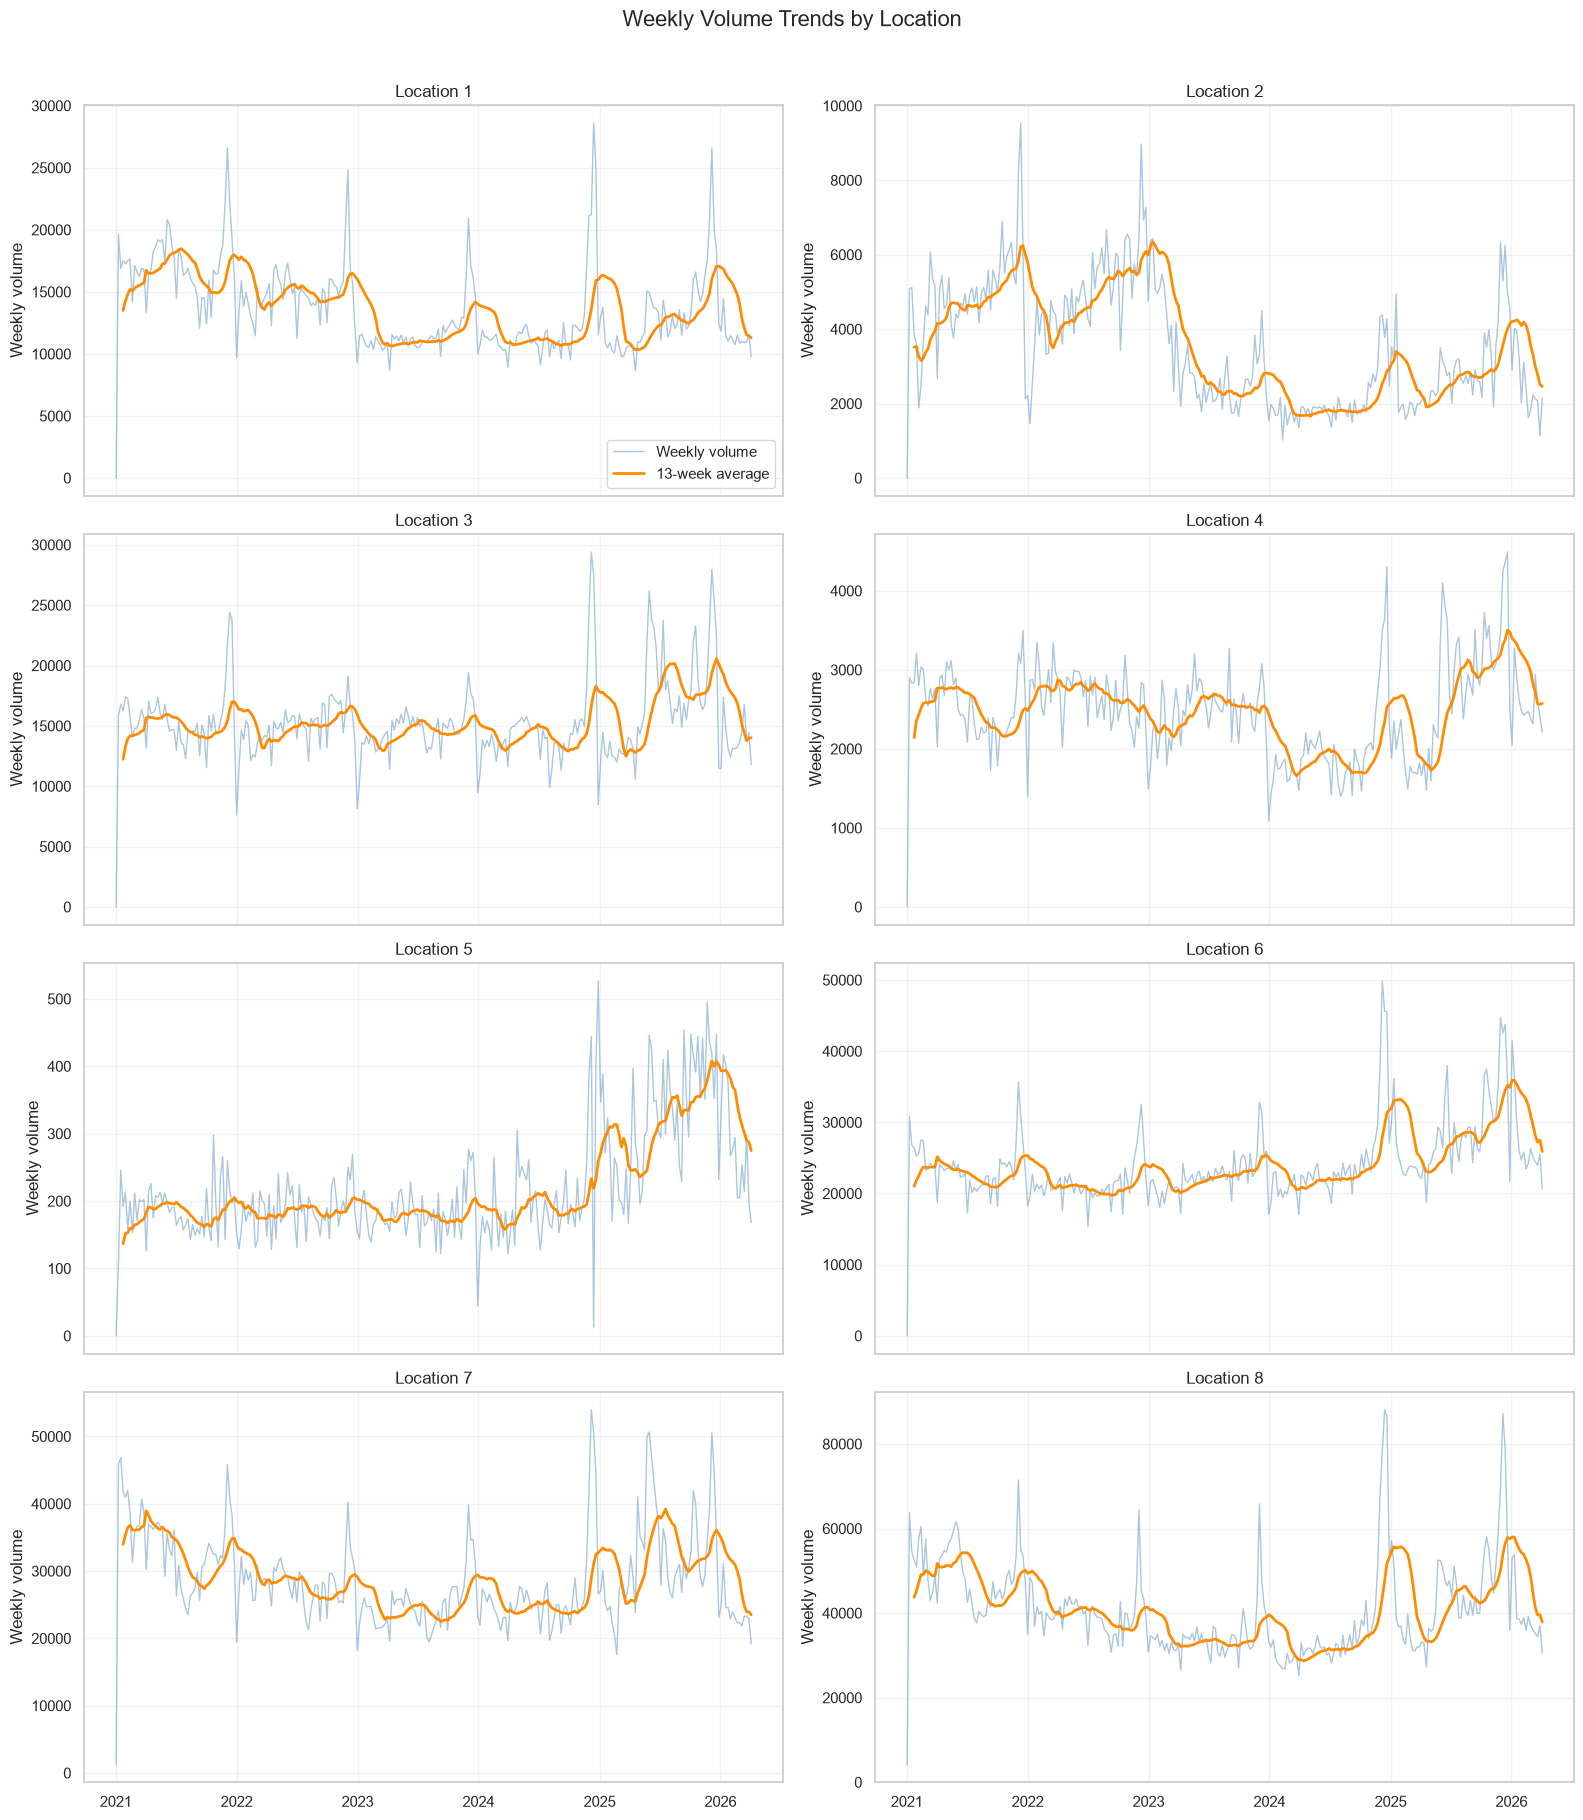

In [161]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(16, 18),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, (location, data) in zip(
    axes,
    weekly_volume.groupby("location")
):
    ax.plot(
        data["Date"],
        data["weekly_volume"],
        color="steelblue",
        alpha=0.45,
        linewidth=1,
        label="Weekly volume"
    )

    ax.plot(
        data["Date"],
        data["rolling_13_week"],
        color="darkorange",
        linewidth=2,
        label="13-week average"
    )

    ax.set_title(f"Location {location}")
    ax.set_ylabel("Weekly volume")
    ax.grid(alpha=0.25)

axes[0].legend()

fig.suptitle(
    "Weekly Volume Trends by Location",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
save_chart(fig,"Weekly Volume Trends by Location")
plt.show()

In [162]:
#creating the yearly data aggregate
df_complete["Date"] = pd.to_datetime(df_complete["Date"])
df_complete["year"] = df_complete["Date"].dt.year
full_year_data = df_complete.loc[
    df_complete["year"].between(2021, 2025)
].copy()

In [163]:
#yearly comparison 
annual_comparison = (
    full_year_data.groupby(["location", "year"])
    .agg(
        annual_volume=("model_volume", "sum"),
        average_daily_volume=("model_volume", "mean"),
        observed_days=("actual", "count"),
        imputed_days=("actual", lambda x: x.isna().sum())
    )
    .reset_index()
)

annual_comparison["year_over_year_change"] = (
    annual_comparison.groupby("location")["annual_volume"]
    .pct_change()
)

annual_comparison

,location,year,annual_volume,average_daily_volume,observed_days,imputed_days,year_over_year_change
0,1,2021,"887,184.50","2,430.64",305,60,NaN
1,1,2022,"775,235.50","2,123.93",279,86,-0.13
2,1,2023,"612,052.17","1,676.86",263,102,-0.21
3,1,2024,"642,931.83","1,756.64",262,104,0.05
4,1,2025,"685,772.75","1,878.83",255,110,0.07
5,2,2021,"254,502.83",697.27,298,67,NaN
6,2,2022,"259,126.00",709.93,271,94,0.02
7,2,2023,"158,354.42",433.85,259,106,-0.39
8,2,2024,"108,560.50",296.61,265,101,-0.31
9,2,2025,"152,788.58",418.60,277,88,0.41


In [164]:
#creating a comparison table for total volume
annual_volume_pivot = annual_comparison.pivot(
    index="location",
    columns="year",
    values="annual_volume"
)

annual_volume_pivot

year,2021,2022,2023,2024,2025
location,,,,,
1,"887,184.50","775,235.50","612,052.17","642,931.83","685,772.75"
2,"254,502.83","259,126.00","158,354.42","108,560.50","152,788.58"
3,"806,121.75","774,088.25","758,956.42","774,662.50","889,797.42"
4,"132,627.50","138,632.08","128,341.58","104,575.08","140,868.67"
5,"9,716.67","9,683.92","9,393.00","10,783.42","16,942.25"
6,"1,226,949.75","1,113,759.75","1,170,490.33","1,273,415.00","1,505,825.33"
7,"1,758,885.25","1,459,414.50","1,302,525.58","1,387,612.83","1,680,891.58"
8,"2,567,977.25","2,069,542.75","1,794,583.58","1,923,382.42","2,334,640.75"


Saved: ..\outputs\figures\Annual Package Volume by Location: 2021–2025.png


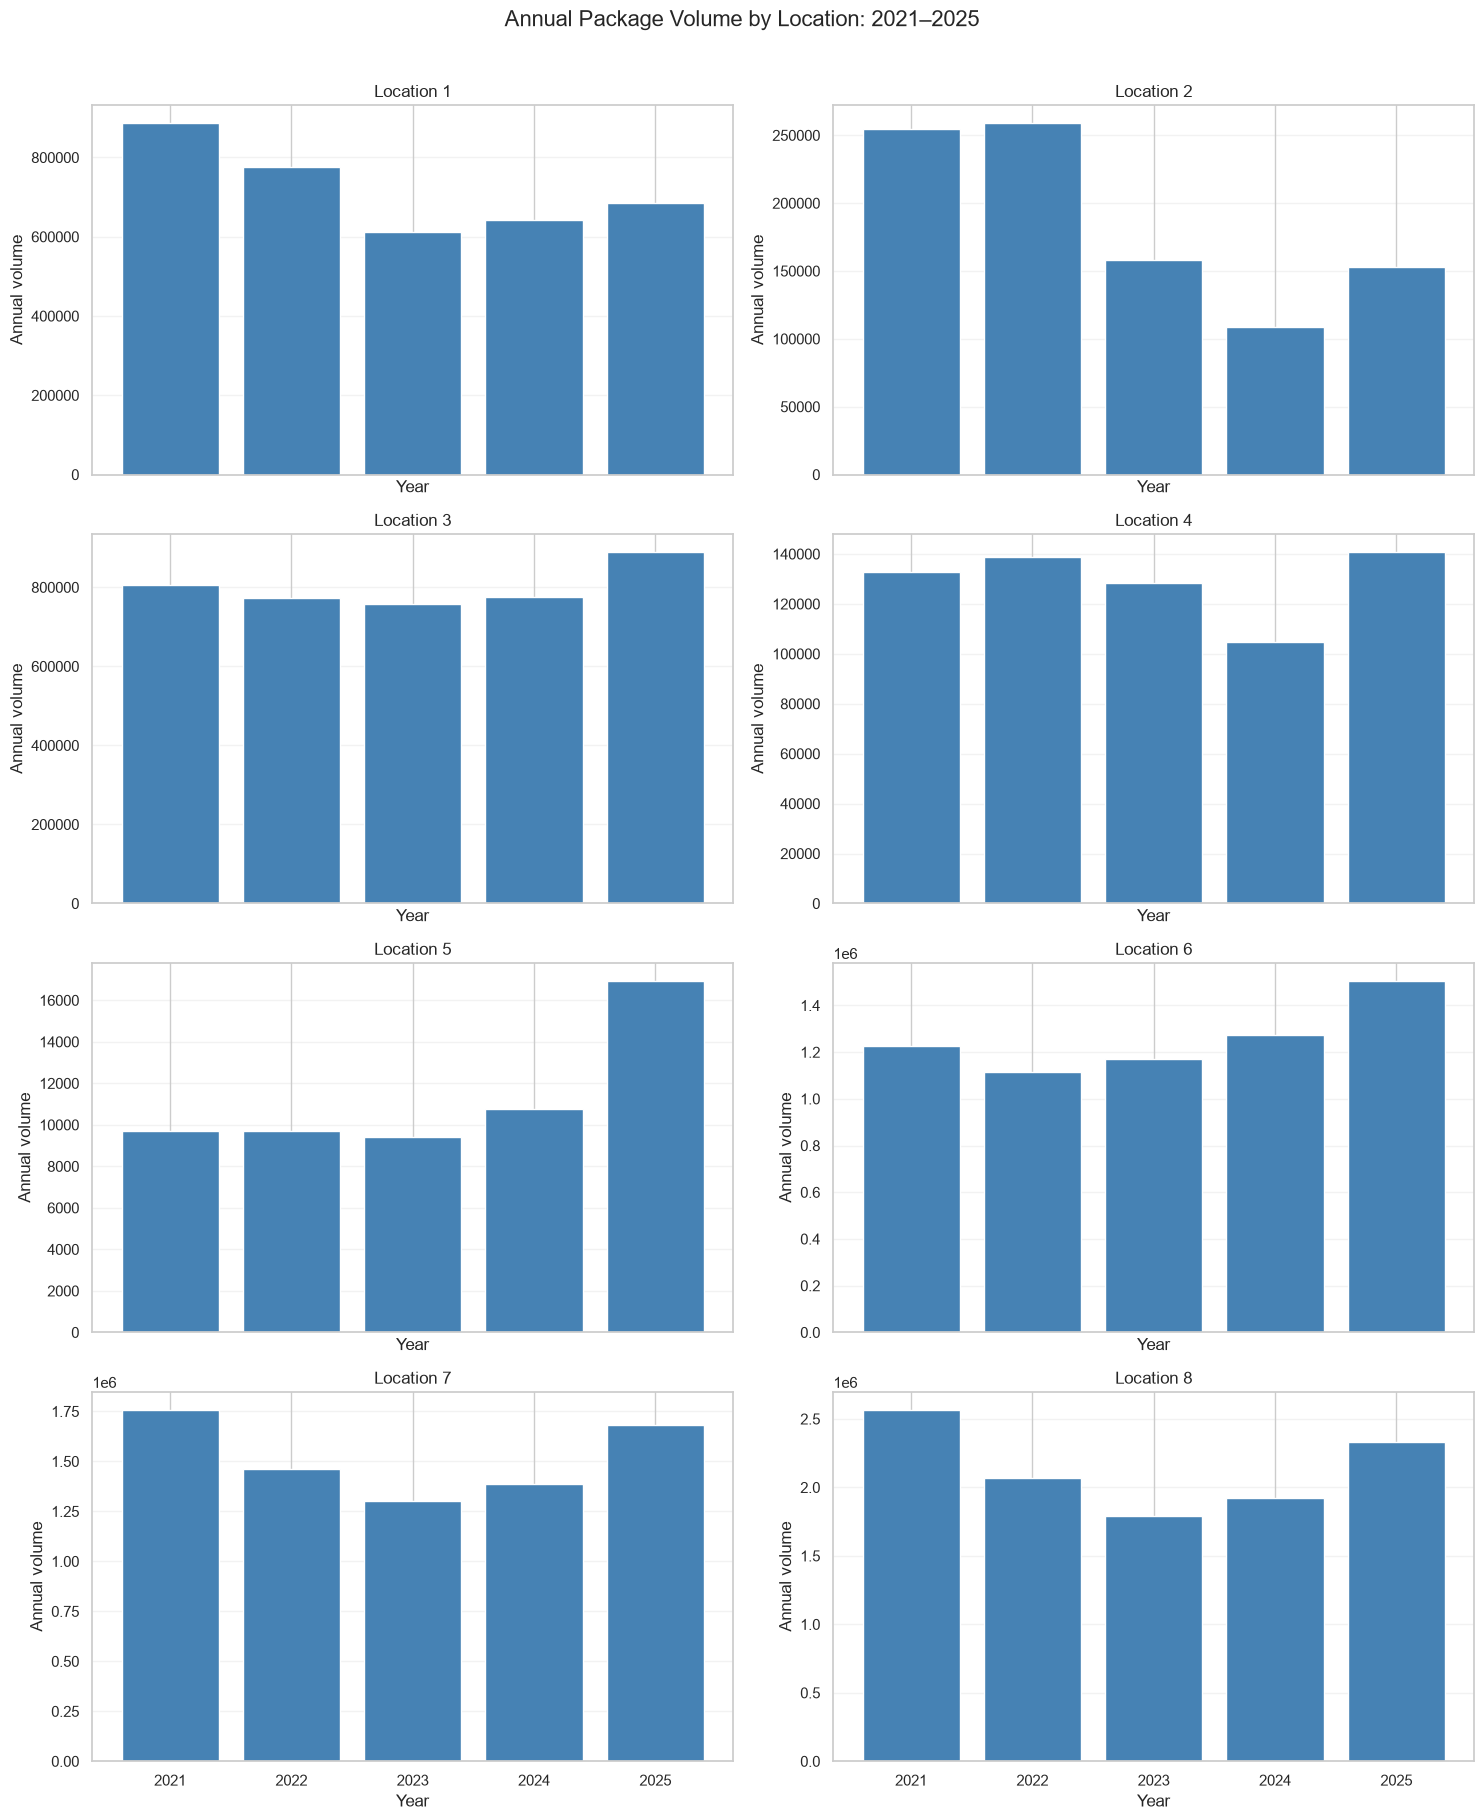

In [165]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(15, 18),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, (location, data) in zip(
    axes,
    annual_comparison.groupby("location")
):
    ax.bar(
        data["year"].astype(str),
        data["annual_volume"],
        color="steelblue"
    )

    ax.set_title(f"Location {location}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual volume")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Annual Package Volume by Location: 2021–2025",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
save_chart(fig,"Annual Package Volume by Location: 2021–2025")
plt.show()

In [166]:
#Volume analysis by weekday
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_profile = (
    df_complete.groupby(["location", "day_of_week"])
    .agg(
        average_volume=("model_volume", "mean"),
        median_volume=("model_volume", "median"),
        standard_deviation=("model_volume", "std"),
        operating_days=("model_volume", lambda x: x.gt(0).sum()),
        calendar_days=("Date", "size")
    )
    .reset_index()
)

weekday_profile["operation_rate"] = (
    weekday_profile["operating_days"] /
    weekday_profile["calendar_days"]
)

In [167]:
weekday_average_pivot = (
    weekday_profile.pivot(
        index="location",
        columns="day_of_week",
        values="average_volume"
    )
    .reindex(columns=weekday_order)
)

weekday_average_pivot

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
location,,,,,,,
1,"2,682.22","2,964.02","2,812.86","2,647.99","2,500.69",70.43,16.00
2,673.97,718.15,682.84,702.75,659.12,76.15,8.67
3,"2,940.69","3,208.23","3,216.16","3,065.04","2,808.00",37.96,0.00
4,456.05,499.91,510.58,479.44,442.75,48.99,39.07
5,42.72,43.57,41.63,33.52,41.84,13.39,3.00
6,"4,553.51","5,027.20","4,840.06","4,849.13","4,510.84",318.16,93.46
7,"5,185.75","5,915.15","5,835.52","5,428.11","5,080.46",720.35,648.12
8,"7,292.44","8,656.09","7,956.34","7,584.58","7,132.08","1,198.77","1,032.49"


Saved: ..\outputs\figures\Average Daily Volume by Location and Weekday.png


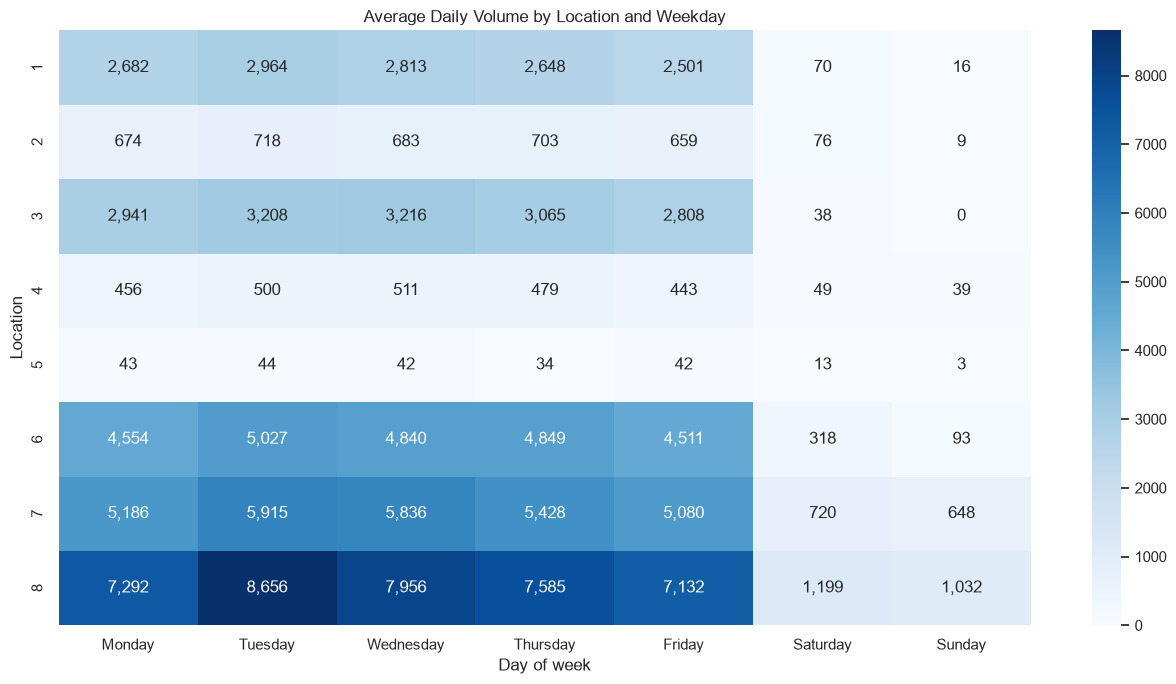

In [168]:
plt.figure(figsize=(13, 7))

sns.heatmap(
    weekday_average_pivot,
    annot=True,
    fmt=",.0f",
    cmap="Blues"
)

plt.title("Average Daily Volume by Location and Weekday")
plt.xlabel("Day of week")
plt.ylabel("Location")
plt.tight_layout()
save_chart(fig,"Average Daily Volume by Location and Weekday")
plt.show()

In [169]:
df_complete["is_operating"] = (
    df_complete["model_volume"]
    .gt(0)
    .astype("int8")
)

In [170]:
operating_summary = (
    df_complete.groupby(["location", "is_operating"])
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={
            0: "non_operating_days",
            1: "operating_days"
        }
    )
    .reset_index()
)

operating_summary

is_operating,location,non_operating_days,operating_days
0,1,546,1374
1,2,480,1440
2,3,557,1363
3,4,435,1485
4,5,521,1399
5,6,44,1876
6,7,33,1887
7,8,33,1887


In [171]:
#saving the processed dataset
processed_data_path = Path(
    "../data/processed/daily_terminal_volume.csv"
)

df_complete.sort_values(
    ["location", "Date"]
).to_csv(
    processed_data_path,
    index=False,
    date_format="%Y-%m-%d"
)

print(f"Dataset saved to: {processed_data_path.resolve()}")

Dataset saved to: F:\Forecasting\Sukh-Forecast\data\processed\daily_terminal_volume.csv


Saved: ..\outputs\figures\Weekly Volume by Year and Location.png


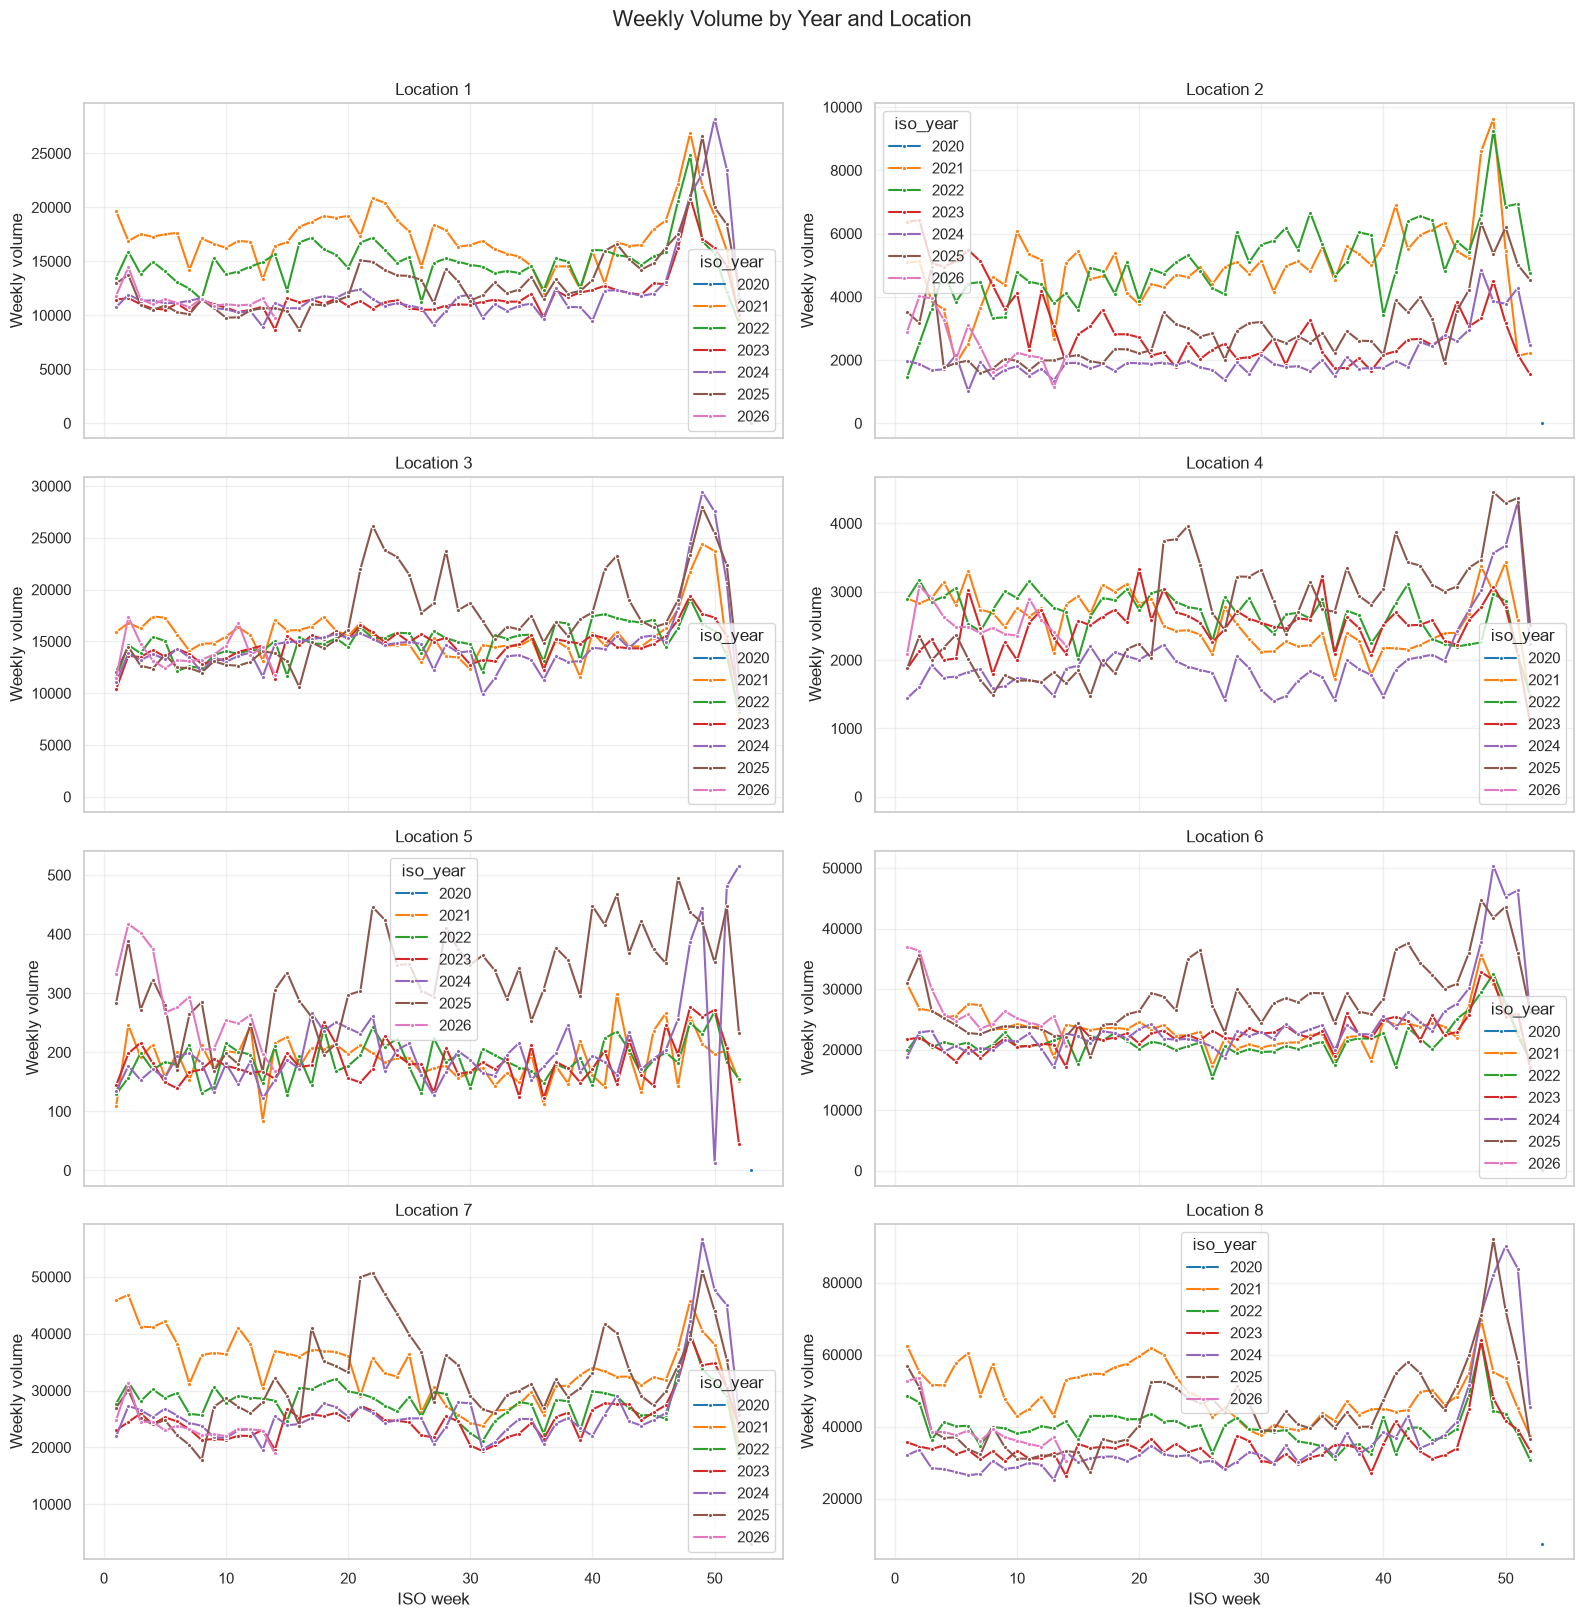

In [172]:
plot_df = df_complete.copy()
plot_df["Date"] = pd.to_datetime(plot_df["Date"])

# Use ISO year/week to handle weeks crossing calendar years correctly
iso_calendar = plot_df["Date"].dt.isocalendar()
plot_df["iso_year"] = iso_calendar["year"].astype(int)
plot_df["iso_week"] = iso_calendar["week"].astype(int)

weekly_volume = (
    plot_df.groupby(
        ["location", "iso_year", "iso_week"],
        as_index=False
    )["model_volume"]
    .sum()
    .rename(columns={"model_volume": "weekly_volume"})
)

fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharex=True)
axes = axes.flatten()

for ax, location in zip(axes, sorted(weekly_volume["location"].unique())):
    location_data = weekly_volume[
        weekly_volume["location"] == location
    ]

    sns.lineplot(
        data=location_data,
        x="iso_week",
        y="weekly_volume",
        hue="iso_year",
        marker="o",
        markersize=3,
        ax=ax,
        palette="tab10"
    )

    ax.set_title(f"Location {location}")
    ax.set_xlabel("ISO week")
    ax.set_ylabel("Weekly volume")
    ax.grid(alpha=0.3)

plt.suptitle("Weekly Volume by Year and Location", fontsize=16, y=1.01)
plt.tight_layout()
save_chart(fig, "Weekly Volume by Year and Location")
plt.show()

Saved: ..\outputs\figures\Average Non-Holiday Weekday Volume by Location.png


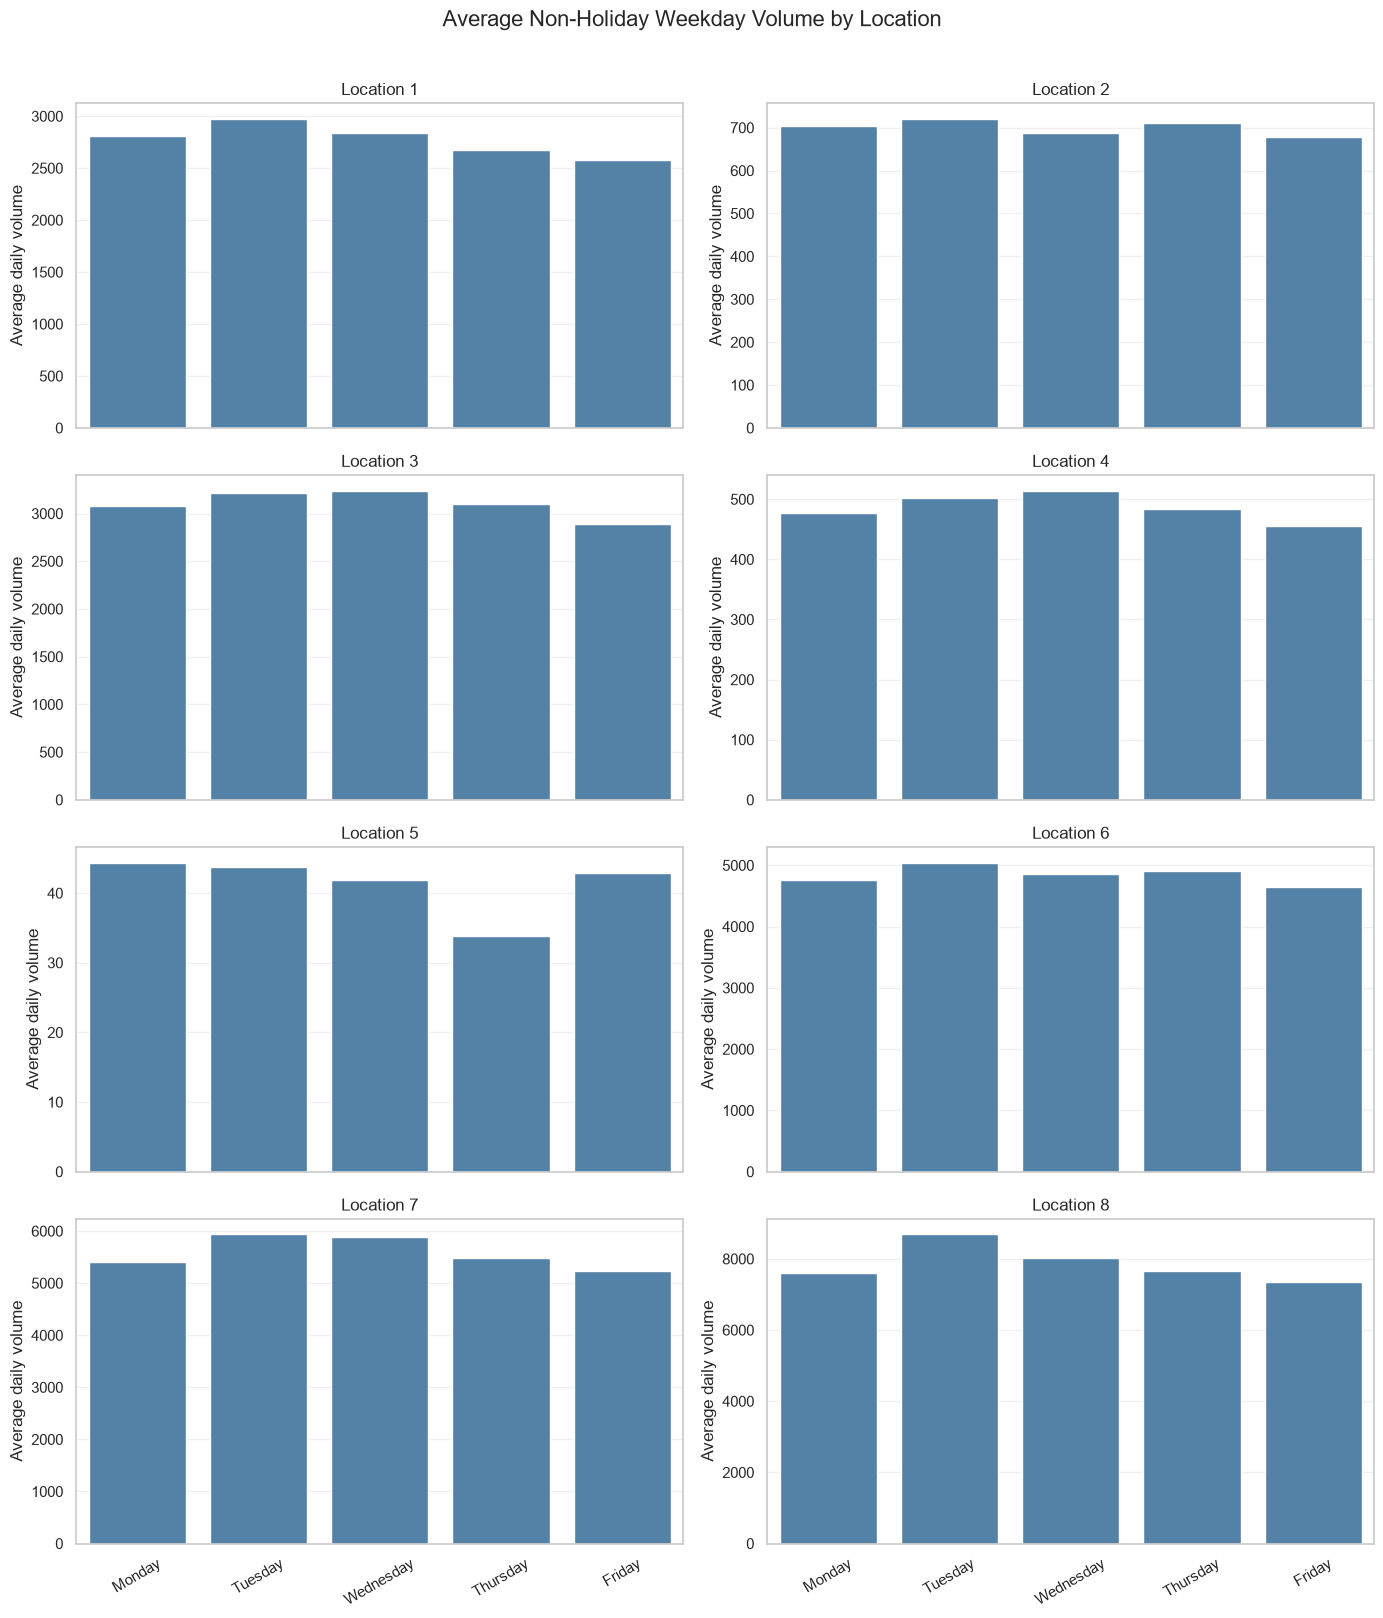

In [173]:
plot_df["weekday_number"] = plot_df["Date"].dt.dayofweek
plot_df["weekday"] = plot_df["Date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

# Ensure the holiday flag is Boolean
plot_df["is_holiday"] = (
    plot_df["is_holiday"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False})
    .fillna(False)
)

weekday_volume = (
    plot_df[
        (plot_df["weekday_number"] < 5) &
        (~plot_df["is_holiday"])
    ]
    .groupby(["location", "weekday"], as_index=False)["model_volume"]
    .mean()
    .rename(columns={"model_volume": "average_volume"})
)

weekday_volume["weekday"] = pd.Categorical(
    weekday_volume["weekday"],
    categories=weekday_order,
    ordered=True
)

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

for ax, location in zip(axes, sorted(weekday_volume["location"].unique())):
    location_data = weekday_volume[
        weekday_volume["location"] == location
    ].sort_values("weekday")

    sns.barplot(
        data=location_data,
        x="weekday",
        y="average_volume",
        ax=ax,
        color="steelblue"
    )

    ax.set_title(f"Location {location}")
    ax.set_xlabel("")
    ax.set_ylabel("Average daily volume")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Average Non-Holiday Weekday Volume by Location",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
save_chart(fig, "Average Non-Holiday Weekday Volume by Location")
plt.show()

Saved: ..\outputs\figures\total_historical_volume_by_location.png.png


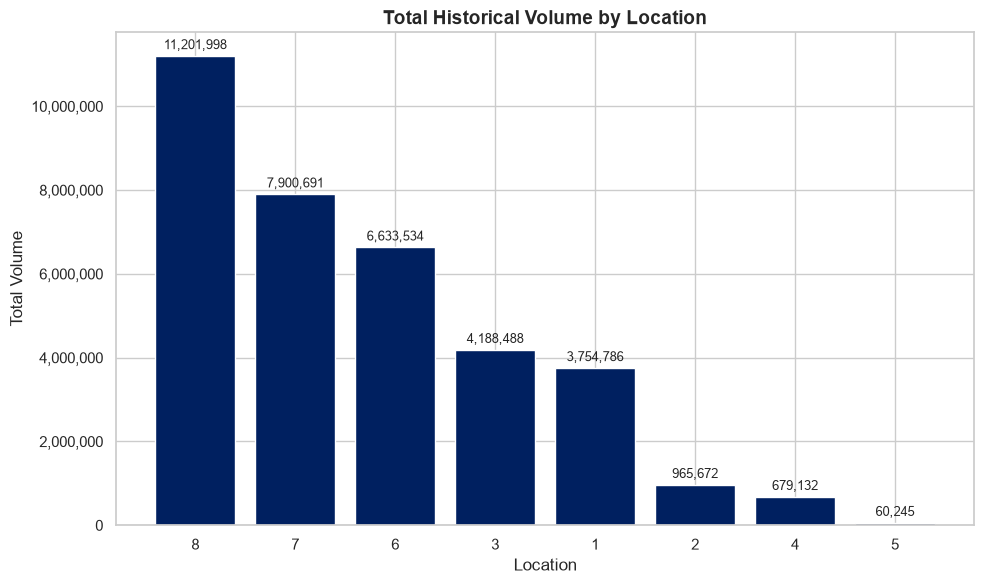

,location,model_volume
7,8,"11,201,998.00"
6,7,"7,900,690.75"
5,6,"6,633,534.42"
2,3,"4,188,488.33"
0,1,"3,754,786.25"
1,2,"965,672.33"
3,4,"679,131.92"
4,5,"60,245.25"


In [176]:
total_volume_by_location = (
    df_complete
    .groupby("location", as_index=False)["model_volume"]
    .sum()
    .sort_values("model_volume", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    total_volume_by_location["location"].astype(str),
    total_volume_by_location["model_volume"],
    color="#002060"
)

ax.set_title("Total Historical Volume by Location", fontsize=14, fontweight="bold")
ax.set_xlabel("Location")
ax.set_ylabel("Total Volume")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:,.0f}")

ax.bar_label(
    bars,
    labels=[f"{value:,.0f}" for value in total_volume_by_location["model_volume"]],
    padding=3,
    fontsize=9
)

plt.tight_layout()
save_chart(fig, "total_historical_volume_by_location.png")
#plt.savefig(FIGURE_DIR / "total_historical_volume_by_location.png", dpi=300, bbox_inches="tight")
plt.show()

total_volume_by_location